# Bonus Task 2 

Numpy and pandas

# Bonus Task 2 - Numpy Section

## 1.1. Create a 1D array containing 20 evenly spaced values between 0 and 1

## 1.2. Create an array containing values from 0 to 99 and reshape it into a 5x20 matrix.

## 1.3. Create a random vector of length 15 and calculate its mean and standard deviation.

In [ ]:

import numpy as np
from numpy.random import randint

In [4]:
# 1.1

np.linspace(0, 1, 20)

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])

In [6]:
# 1.2

vals = np.linspace(0,99,100)


mat = vals.reshape(5,20)

print(mat)

[[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
  18. 19.]
 [20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37.
  38. 39.]
 [40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54. 55. 56. 57.
  58. 59.]
 [60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77.
  78. 79.]
 [80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96. 97.
  98. 99.]]


In [8]:
# 1.3


vec = randint(1,10000,15)
vec_mean = np.mean(vec)
vec_stdev = np.std(vec)
print(vec_mean)
print(vec_stdev)



 

5455.0
2755.7044108539653


# Bonus Task 2 - Pandas Section - Titanic

Loading Titanic data (install Seaborn if needed: pip install seaborn):

```python
import seaborn as sns
titanic = sns.load_dataset('titanic')
```

## 2.1. Calculate the survival percentages of Titanic passengers based on gender and travel class (1st, 2nd, 3rd class).

## 2.2. Did ticket price (Fare) have an impact on survival?

Hint: Group the ticket price by travel class and use the agg() function to analyze the average.

In [ ]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
titanic = sns.load_dataset('titanic')
t = titanic[['survived', 'fare', 'class', 'sex']].dropna()

In [12]:

t.groupby(['sex', 'class'])['survived'].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

In [14]:
# 2.2


corr = t['survived'].corr(t['fare'])

print("Correlation of higher fare to survial rate overall")
print("Plain correlation")
print(corr)

print("Correlation of higher fare for survival by sex")
for s, df in t.groupby('sex'):
    print(s, df['survived'].corr(t['fare']))

surv = t.loc[t['survived']==1, 'fare']
nonsurv = t.loc[t['survived']==0, 'fare']



print(surv)
print(nonsurv)

tstat, pval = stats.ttest_ind(surv,nonsurv,equal_var=False)
print("T test results")
print(f"tval {tstat}, pval {pval}")

Correlation of higher fare to survial rate overall
Plain correlation
0.2573065223849625
Correlation of higher fare for survival by sex
female 0.2184659347355378
male 0.17128817503516802
1      71.2833
2       7.9250
3      53.1000
8      11.1333
9      30.0708
        ...   
875     7.2250
879    83.1583
880    26.0000
887    30.0000
889    30.0000
Name: fare, Length: 342, dtype: float64
0       7.2500
4       8.0500
5       8.4583
6      51.8625
7      21.0750
        ...   
884     7.0500
885    29.1250
886    13.0000
888    23.4500
890     7.7500
Name: fare, Length: 549, dtype: float64
T test results
tval 6.839099259085254, pval 2.6993323503141203e-11


Text(0.5, 0, 'fare')

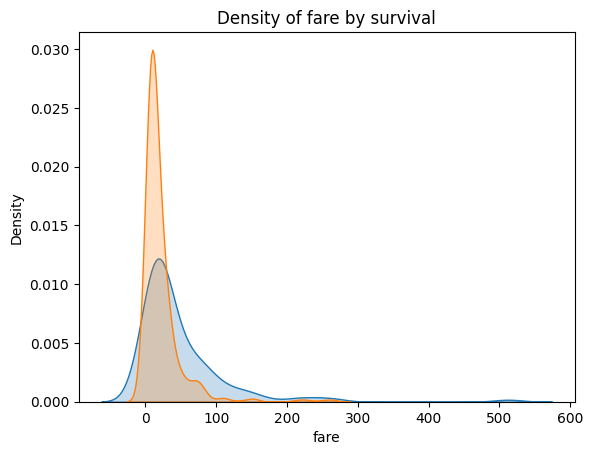

In [15]:

sns.kdeplot(t.loc[t['survived']==1, 'fare'], label='survived=1', fill=True)
sns.kdeplot(t.loc[t['survived']==0, 'fare'], label='survived=0', fill=True)
plt.title("Density of fare by survival")
plt.xlabel("fare")


